In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

In [11]:
df_index=pd.read_csv("economic_index.csv")

In [12]:
df_index.head()

,Unnamed: 0,year,month,interest_rate,unemployment_rate,index_price
0,0,2017,12,2.75,5.3,1464
1,1,2017,11,2.50,5.3,1394
2,2,2017,10,2.50,5.3,1357
3,3,2017,9,2.50,5.3,1293
4,4,2017,8,2.50,5.4,1256


In [13]:
#Drop unnecessary columns

df_index.drop(columns=["Unnamed: 0","month","year"],axis=1,inplace=True)


inplace=True...dropping all the necessary columns from the dataset

In [14]:
df_index.head()

,interest_rate,unemployment_rate,index_price
0,2.75,5.3,1464
1,2.50,5.3,1394
2,2.50,5.3,1357
3,2.50,5.3,1293
4,2.50,5.4,1256


In [15]:
#Check null values

df_index.isnull().sum()

interest_rate        0
unemployment_rate    0
index_price          0
dtype: int64

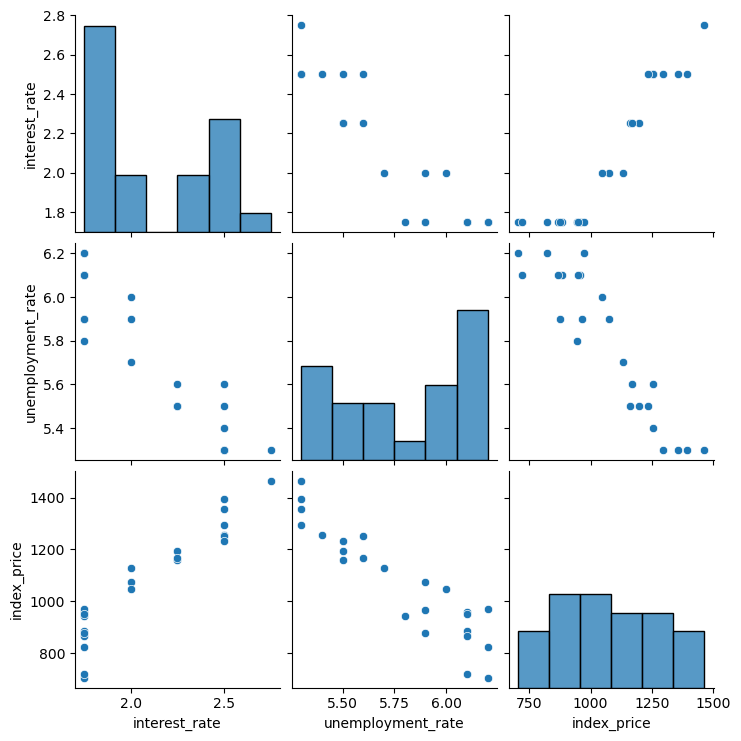

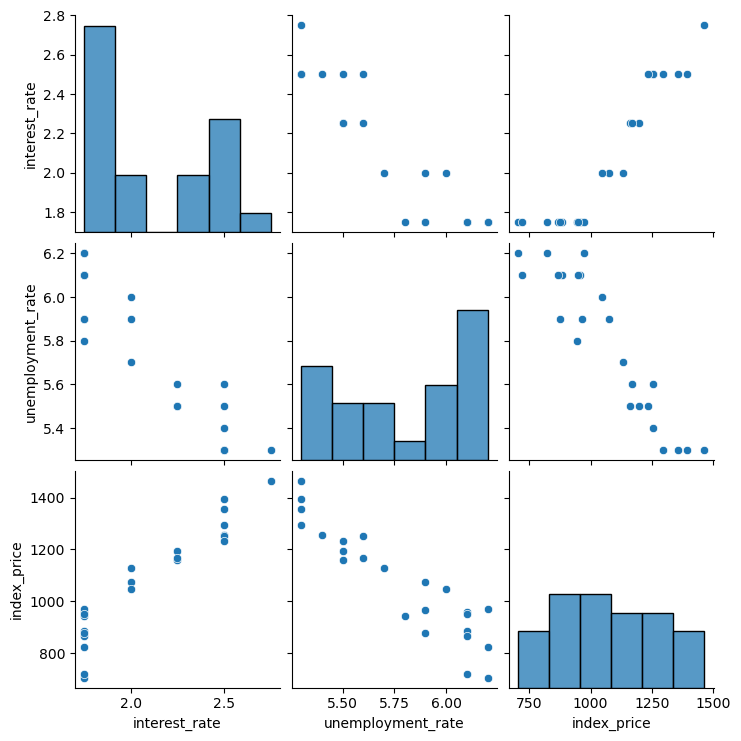

In [17]:
#Lets do some visualization

import seaborn as sns
sns.pairplot(df_index)
plt.show()

In [18]:
df_index.corr()

,interest_rate,unemployment_rate,index_price
interest_rate,1.000000,-0.925814,0.935793
unemployment_rate,-0.925814,1.000000,-0.922338
index_price,0.935793,-0.922338,1.000000


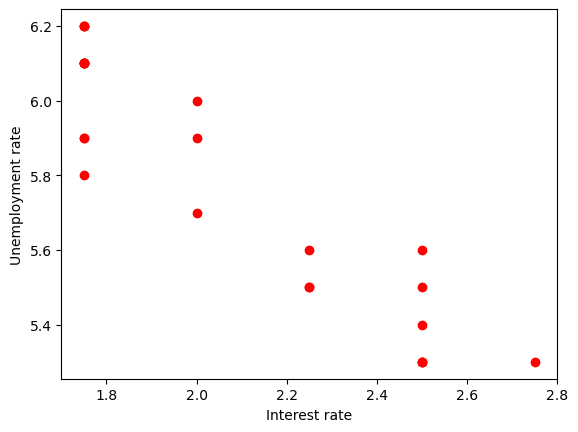

In [22]:
#Visualize the datapoints from closely

plt.scatter(df_index['interest_rate'],df_index['unemployment_rate'],color='r')
plt.xlabel("Interest rate")
plt.ylabel("Unemployment rate")
plt.show()

In [23]:
#Independent and Depenedent features

X=df_index.iloc[:,:-1]
y=df_index.iloc[:,-1]

In [24]:
X.head()

,interest_rate,unemployment_rate
0,2.75,5.3
1,2.50,5.3
2,2.50,5.3
3,2.50,5.3
4,2.50,5.4


In [25]:
y

0     1464
1     1394
2     1357
3     1293
4     1256
5     1254
6     1234
7     1195
8     1159
9     1167
10    1130
11    1075
12    1047
13     965
14     943
15     958
16     971
17     949
18     884
19     866
20     876
21     822
22     704
23     719
Name: index_price, dtype: int64

In [50]:
#Train test Split

from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=42)

In [51]:
import seaborn as sns

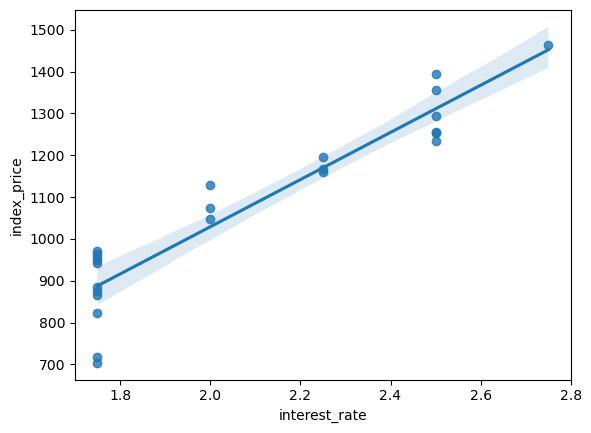

In [52]:
sns.regplot(x=df_index['interest_rate'],y=df_index['index_price'])
plt.show()

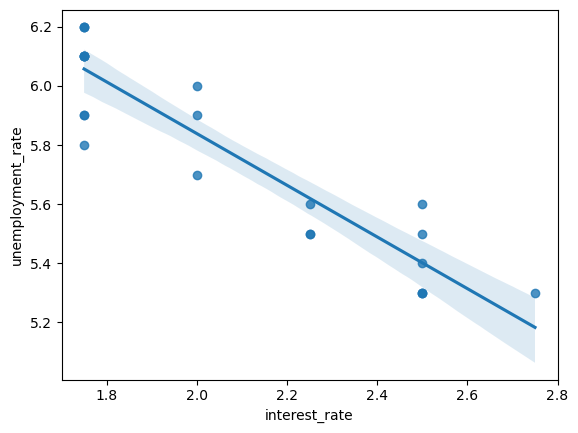

In [53]:
sns.regplot(x=df_index['interest_rate'],y=df_index['unemployment_rate'])
plt.show()

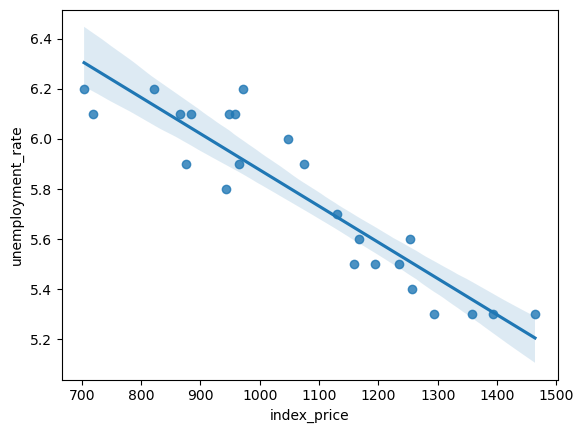

In [54]:
sns.regplot(x=df_index['index_price'],y=df_index['unemployment_rate'])
plt.show()

In [55]:
from sklearn.preprocessing import StandardScaler

In [56]:
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [57]:
X_train

array([[-0.90115511,  0.37908503],
       [ 1.31077107, -1.48187786],
       [-0.90115511,  1.30956648],
       [ 1.31077107, -0.55139641],
       [ 1.31077107, -1.48187786],
       [-0.16384638,  0.68924552],
       [-0.90115511,  0.999406  ],
       [ 1.31077107, -1.48187786],
       [ 1.31077107, -1.17171738],
       [-0.90115511,  1.30956648],
       [-0.90115511,  0.999406  ],
       [-0.90115511,  0.37908503],
       [-0.90115511,  0.999406  ],
       [ 0.57346234, -0.8615569 ],
       [-0.16384638, -0.24123593],
       [-0.90115511,  0.06892455],
       [-0.90115511,  0.999406  ],
       [ 1.31077107, -0.8615569 ]])

In [58]:
X_test

array([[ 0.57346234, -0.8615569 ],
       [-0.90115511,  1.30956648],
       [ 2.0480798 , -1.48187786],
       [-0.90115511,  0.999406  ],
       [-0.16384638,  0.37908503],
       [ 0.57346234, -0.55139641]])

In [59]:
from sklearn.linear_model import LinearRegression
regression=LinearRegression()

In [60]:
regression.fit(X_train,y_train)

LinearRegression()

Cross Validation

In [61]:
from sklearn.model_selection import cross_val_score
validation_score=cross_val_score(regression,X_train,y_train,scoring='neg_mean_squared_error',cv=3)

In [62]:
validation_score

array([-4921.61331265, -7686.87497294, -5135.9962549 ])

In [63]:
np.mean(validation_score)

-5914.828180162396

In [64]:
from sklearn.model_selection import cross_val_score
validation_score1=cross_val_score(regression,X_train,y_train,scoring='r2',cv=3)

In [65]:
validation_score1

array([0.88856676, 0.82159918, 0.85226213])

In [66]:
np.mean(validation_score1)

0.8541426890278223

Prediction

In [67]:
y_pred=regression.predict(X_test)

Performance metrics

In [68]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [72]:
mse=mean_squared_error(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
r2=r2_score(y_test,y_pred)
rmse=np.sqrt(mse)
print(mse)
print(mae)
print(rmse)
print(r2)

5793.76288771258
59.93578152323556
76.11677139574813
0.8278978091457142


Assumptions

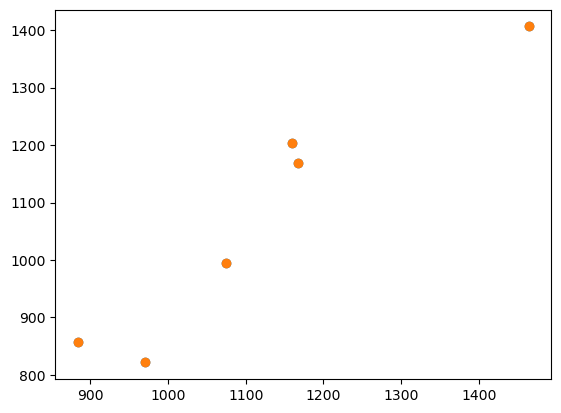

In [74]:
plt.scatter(y_test,y_pred)
plt.show()

In [75]:
residuals=y_test-y_pred
print(residuals)

8     -45.227704
16    149.349481
0      57.486996
18     26.291104
11     80.090077
9      -1.169327
Name: index_price, dtype: float64


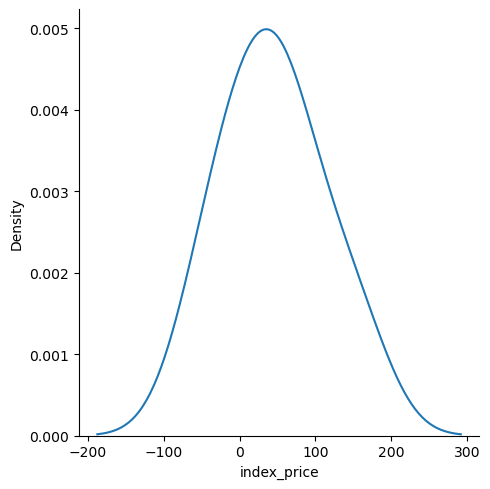

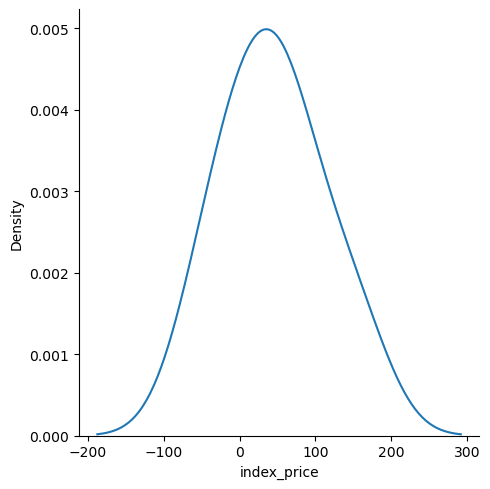

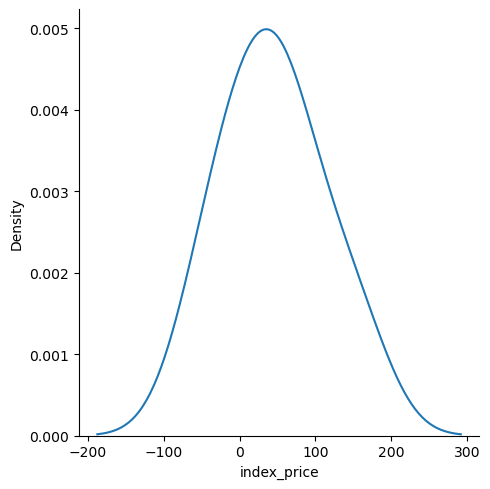

In [78]:
#Plot the residuals

sns.displot(residuals,kind='kde')
plt.show()

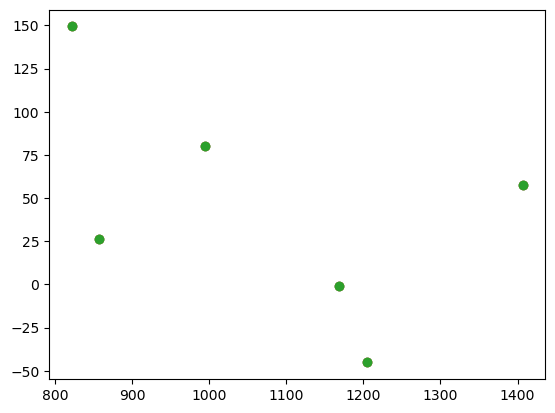

In [81]:
#scatter plot with respect to prediction and residulas

plt.scatter(y_pred,residuals)
plt.show()

OLS Linear Regression

In [82]:
import statsmodels.api as sm
model=sm.OLS(y_train,X_train).fit()

In [83]:
model.summary()

c:\Users\cheta\anaconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:531: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=18
  res = hypotest_fun_out(*samples, **kwds)


<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:            index_price   R-squared (uncentered):                   0.035
Model:                            OLS   Adj. R-squared (uncentered):             -0.086
Method:                 Least Squares   F-statistic:                             0.2880
Date:                Sun, 01 Jun 2025   Prob (F-statistic):                       0.754
Time:                        13:43:57   Log-Likelihood:                         -150.85
No. Observations:                  18   AIC:                                      305.7
Df Residuals:                      16   BIC:                                      307.5
Df Model:                           2                                                  
Covariance Type:            nonrobust                                                  
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
x1            88.2728    658.295      0.134      0.895   -1307.250    1483.796
x2          -116.2572    658.295     -0.177      0.862   -1511.780    1279.266
==============================================================================
Omnibus:                        0.598   Durbin-Watson:                   0.007
Prob(Omnibus):                  0.741   Jarque-Bera (JB):                0.567
Skew:                          -0.361   Prob(JB):                        0.753
Kurtosis:                       2.517   Cond. No.                         4.78
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [84]:
print(regression.coef_)

[  88.27275507 -116.25716066]
